In [19]:
import json
import sys
from pathlib import Path

def sum_counts(json_path: str) -> int:
    json_path = Path(json_path)
    if not json_path.exists():
        raise FileNotFoundError(f"File not found: {json_path}")

    with open(json_path, "r") as f:
        data = json.load(f)

    total = 0
    for key, items in data.items():
        for obj in items:
            total += obj.get("count", 0)

    return total

In [20]:
import json
from pathlib import Path

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"
# Load and sum counts
data = json.loads(Path(json_path).read_text())

total_count = 0
for key, items in data.items():
    for obj in items:
        total_count += obj.get("count", 0)

print(f"Total count = {total_count}")


Total count = 2860860219


In [21]:
import json
from pathlib import Path

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"
# Load JSON
data = json.loads(Path(json_path).read_text())

# Collect all distinct field names
distinct_fields = set()

for key, items in data.items():
    for obj in items:
        fields = obj.get("fields", [])
        distinct_fields.update(fields)

print("Total distinct field count:", len(distinct_fields))
print("Distinct fields:", distinct_fields)


Total distinct field count: 330
Distinct fields: {'cold', 'size', 'envp', 'prot_op', 'rgid', 'flags', 'old_tid', 'ufds', 'act', 'diskname', 'cmd_len', 'irq', 'child_comm', 'sigmask', 'nr_rq', 'advice', 'sa_handler', 'zid', 'write_op', 'v4addr', 'infop', 'nset', 'val', 'clone_flags', 'prev_tid', 'vpid', 'hrtimer', 'newsp', 'shrink', 'runtime', 'prev_state', 'gfp_flags', 'argv', 'optval', '_cmd_length', 'how', 'off_out', 'ruid', 'value', 'submode', 'old_len', 'umyaddr', 'val3', 'flag', 'softexpires', 'sector', 'parent_comm', 'dest_cpu', 'id', 'uid', 'locked', 'forced_to_close', '_vtids_length', 'optlen', 'timer', 'entropy_count', 'logging', 'level', 'suid', 'sport', 'call_site', 'tid', 'filename', 'transaction', 'usockaddr_len', 'utmr', 'pfn', 'moved', 'target_cpu', 'vruntime', 'sigsetsize', 'new_len', 'block_nr', 'oldfd', 'path', 'value_usec', 'handle_count', 'dev_name', 'usec_delayed', 'pgid', 'child_tid', 'error_code', 'fd_out', 'utimes', 'unused_scan', 'prot', 'parent_tid', 'bytes_re

In [22]:
import json
from pathlib import Path
from collections import Counter

# Path to your JSON file
json_path = "./metadata_all_events/event_schemas.json"

# Load JSON
data = json.loads(Path(json_path).read_text())

# Counter for all field occurrences
field_counter = Counter()

for key, items in data.items():
    for obj in items:
        fields = obj.get("fields", [])
        field_counter.update(fields)

# Display results
for field, count in field_counter.most_common():
    print(f"{field}: {count}")


cpu_id: 384
ret: 124
fd: 36
name: 25
dev: 23
tid: 22
flags: 22
comm: 19
len: 14
filename: 13
sector: 12
mode: 12
vector: 10
nr_sector: 10
rwbs: 10
pathname: 10
buf: 9
prio: 8
order: 8
gfp_flags: 7
cmd: 7
ino: 7
size: 7
pid: 7
skbaddr: 7
dfd: 7
call_site: 6
ptr: 6
state: 6
page: 6
pfn: 6
function: 6
id: 6
IP: 6
count: 6
sync_commit: 6
transaction: 6
offset: 5
timer: 5
pool_name: 5
hrtimer: 5
addr: 5
which: 5
nid: 5
bytes_alloc: 4
bytes_req: 4
arg: 4
nbytes: 4
_cmd_length: 4
bytes: 4
now: 4
work: 4
msg: 4
statbuf: 4
error_code: 4
sig: 4
ufds: 4
arg2: 4
upeer_addrlen: 4
target_cpu: 3
migratetype: 3
expires: 3
_cmnd_length: 3
channel: 3
cmd_len: 3
cmnd: 3
data_sglen: 3
host_no: 3
lun: 3
opcode: 3
prot_op: 3
prot_sglen: 3
irq: 3
vec: 3
entropy_count: 3
ip: 3
ru: 3
sigsetsize: 3
args: 3
fildes: 3
family: 3
addr_len: 3
optlen: 3
arg3: 3
arg4: 3
arg5: 3
newname: 3
oldname: 3
sync_mode: 3
who: 3
node: 2
result: 2
errors: 2
type: 2
epfd: 2
how: 2
prot: 2
address: 2
code: 2
errno: 2
options: 2
up

<Figure size 1000x900 with 0 Axes>

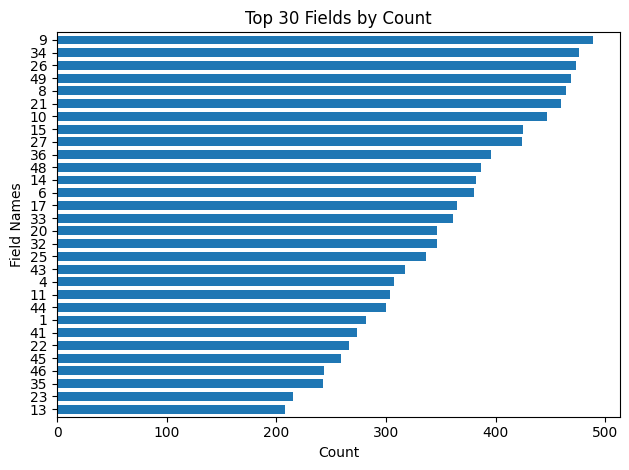

In [23]:
# First, let's ensure we have the necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create or load your data
# Option 1: If you need to create sample data
data = {
    'field_name': ['Field_' + str(i) for i in range(50)],
    'count': np.random.randint(10, 500, size=50)
}
df = pd.DataFrame(data)

# Create df_fields (assuming this is what you intended)
df_fields = df  # Or some transformation of your original data

# Now your original code should work
top_n = 30
df_top = df_fields.sort_values('count', ascending=False).head(top_n)

plt.figure(figsize=(10, top_n * 0.3))
df_top.sort_values('count').plot(kind='barh', legend=False, width=0.7)
plt.xlabel('Count')
plt.ylabel('Field Names')
plt.title('Top {} Fields by Count'.format(top_n))
plt.tight_layout()
plt.show()

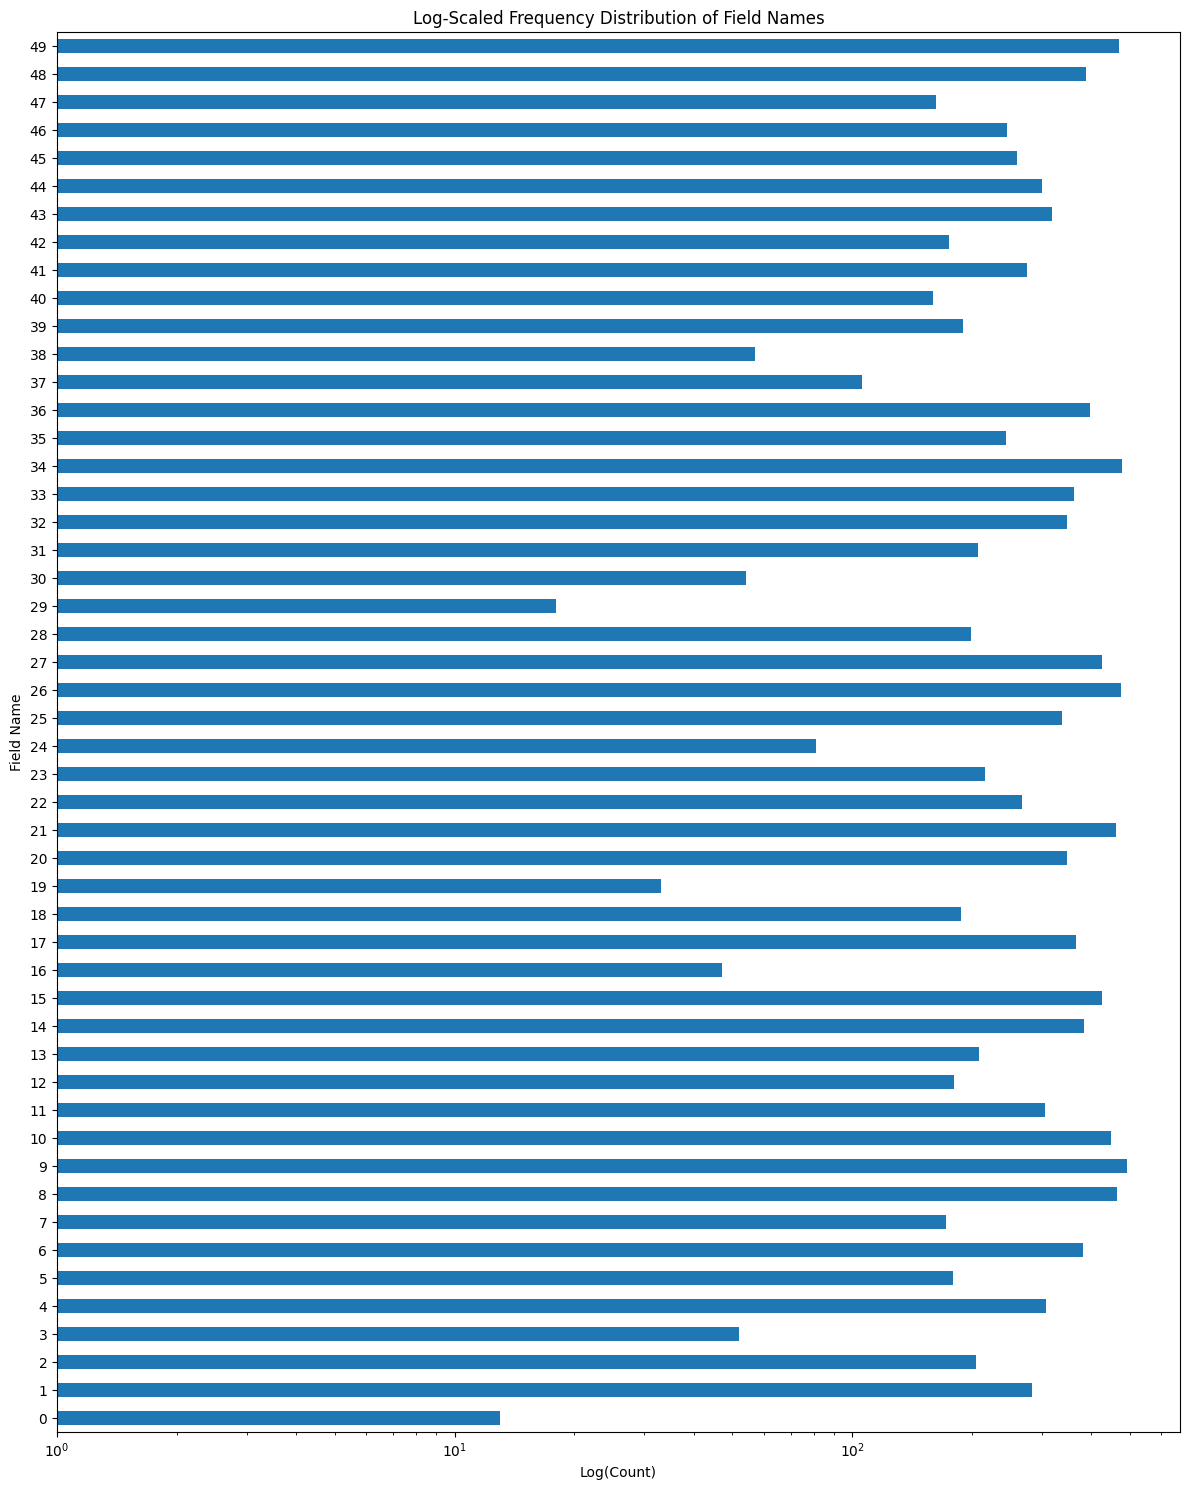

In [24]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, max(6, len(df_fields) * 0.3)))
df_fields['count'].plot(kind='barh', log=True)
plt.title("Log-Scaled Frequency Distribution of Field Names")
plt.xlabel("Log(Count)")
plt.ylabel("Field Name")
plt.tight_layout()
plt.show()


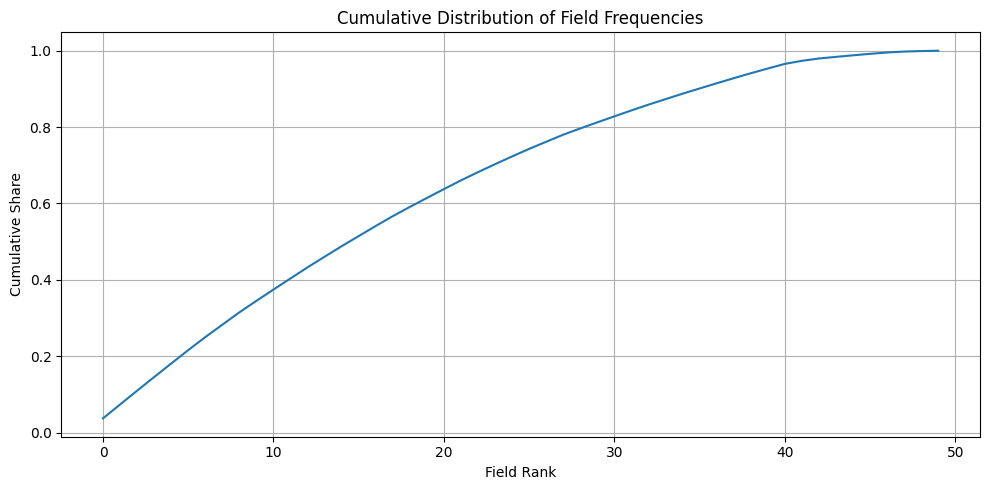

In [25]:
df_cum = df_fields.sort_values('count', ascending=False)
df_cum['cumulative'] = df_cum['count'].cumsum() / df_cum['count'].sum()

plt.figure(figsize=(10, 5))
plt.plot(df_cum['cumulative'].values)
plt.title("Cumulative Distribution of Field Frequencies")
plt.xlabel("Field Rank")
plt.ylabel("Cumulative Share")
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
pq_path = r"enriched_parquets/scimark2/scimark2-all-events-run0.parquet"

In [27]:
import pandas as pd
import pyarrow.parquet as pq

# Set display option to avoid scientific notation
pd.set_option('display.float_format', '{:.10f}'.format)

start, stop = 0, 10

pf = pq.ParquetFile(pq_path)
tbl = pf.read()
df = tbl.to_pandas().iloc[start:stop]

display(df)

,line_idx,ts_str,delta_s,t_rel_ns,event_name,event_id,cpu_id,tid,pid,comm,ret,fd,filename,flags,state,extra_params
0,0,09:32:47.799444243,0.0000000000,0,kmem_kmalloc,20,0,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064615, ""ptr"": 184..."
1,1,09:32:47.799446983,0.0000027400,2740,kmem_kfree,19,0,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064826, ""ptr"": 184..."
2,2,09:32:47.799447463,0.0000004800,3220,sched_waking,33,0,2208.0000000000,NaN,lttng-consumerd,NaN,NaN,None,None,NaN,"{""prio"": 20, ""target_cpu"": 3}"
3,3,09:32:47.799448349,0.0000008860,4106,sched_wakeup,34,0,2208.0000000000,NaN,lttng-consumerd,NaN,NaN,None,None,NaN,"{""prio"": 20, ""target_cpu"": 3}"
4,4,09:32:47.799448976,0.0000006270,4733,power_cpu_idle,23,3,NaN,NaN,None,NaN,NaN,None,None,4294967295.0000000000,None
5,5,09:32:47.799449491,0.0000005150,5248,kmem_kmalloc,20,0,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064615, ""ptr"": 184..."
6,6,09:32:47.799449783,0.0000002920,5540,rcu_utilization,18,3,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""s"": ""Start context switch""}"
7,7,09:32:47.799450074,0.0000002910,5831,rcu_utilization,18,3,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""s"": ""End context switch""}"
8,8,09:32:47.799450353,0.0000002790,6110,sched_switch,25,3,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""prev_comm"": ""swapper/3"", ""prev_tid"": 0, ""pre..."
9,9,09:32:47.799450571,0.0000002180,6328,kmem_kfree,19,0,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""call_site"": 18446744072109064826, ""ptr"": 184..."


In [28]:
df = tbl.to_pandas()
df.tail()

,line_idx,ts_str,delta_s,t_rel_ns,event_name,event_id,cpu_id,tid,pid,comm,ret,fd,filename,flags,state,extra_params
715800,715800,09:33:17.390662908,0.0000001090,29591218665,x86_irq_vectors_call_function_single_exit,202,1,NaN,NaN,None,NaN,NaN,None,None,NaN,"{""vector"": 251}"
715801,715801,09:33:17.390663088,0.0000001800,29591218845,syscall_entry_ioctl,95,0,NaN,NaN,None,NaN,31.0000000000,None,None,NaN,"{""cmd"": 62988, ""arg"": 1000}"
715802,715802,09:33:17.390663826,0.0000007380,29591219583,syscall_exit_ioctl,96,0,NaN,NaN,None,0.0000000000,NaN,None,None,NaN,"{""arg"": 1000}"
715803,715803,09:33:17.390664507,0.0000006810,29591220264,syscall_entry_ioctl,95,0,NaN,NaN,None,NaN,33.0000000000,None,None,NaN,"{""cmd"": 63063, ""arg"": 1000}"
715804,715804,09:33:17.390664846,0.0000003390,29591220603,power_cpu_idle,23,1,NaN,NaN,None,NaN,NaN,None,None,5.0000000000,None


In [29]:
df.columns.tolist()

['line_idx',
 'ts_str',
 'delta_s',
 't_rel_ns',
 'event_name',
 'event_id',
 'cpu_id',
 'tid',
 'pid',
 'comm',
 'ret',
 'fd',
 'filename',
 'flags',
 'state',
 'extra_params']

In [30]:
df = tbl.to_pandas()

In [31]:
df['event_id'].nunique()

273

In [32]:
df['event_id'].unique()

array([ 20,  19,  33,  34,  23,  18,  25, 117,   8,  95, 115, 116,   7,
        96,  45,   1,  46,  10,  13,  11,  14,  12,  15,   0,  53,  52,
       158,  51,  55,  73,  76,  58,  75,  57,  59,  71,  54,  24,   5,
        29,  21,  31,  26,  32,  22,  30,  27,  28,  39,  41,  42,  40,
       297, 139, 104, 206, 277,  89,  92,  93, 101, 102, 255,  90,  91,
       298, 151, 179, 180,  35,  36, 118,  94, 140, 114, 137, 271, 272,
        49,  50,  62,  63,   9,   2,   3, 148,   6,   4, 141, 147, 153,
        83,  84, 166, 167, 171, 154, 144, 131, 170,  17,  16, 126, 127,
       152, 103, 142, 143, 121,  56, 155, 149, 146, 111, 150, 156,  99,
       100,  85,  86,  43,  44,  80,  81, 145,  97,  98, 174, 175, 161,
       162, 176, 177,  47,  48,  78,  79, 214, 215, 134, 135, 238, 239,
        87,  88, 285, 286, 262, 225, 226, 249, 250, 265, 266, 186, 187,
       159, 160, 181, 182, 232, 233, 107, 108,  37,  38, 183, 184, 199,
       200, 227, 157, 228, 204, 205,  68,  72,  69,  70, 106, 10

In [33]:
df['cpu_id'].nunique()

4

In [34]:
df['cpu_id'].unique()

array([0, 3, 2, 1], dtype=int32)

In [35]:
df['tid'].nunique()

316

In [36]:
df['tid'].astype('Int64').unique()

<IntegerArray>
[<NA>, 2208, 2186,    7,    1,    2,    3,    5,    8,    9,
 ...
 5246, 5247, 5248, 5249, 5250, 5251, 5252, 5253, 5254, 5255]
Length: 317, dtype: Int64

In [37]:
df['pid'].nunique()

188

In [38]:
df['pid'].astype('Int64').unique()

<IntegerArray>
[<NA>,    1,    2,    3,    5,    7,    8,    9,   10,   11,
 ...
 5237, 5240, 5239, 5241, 5243, 5245, 5247, 5249, 5251, 5124]
Length: 189, dtype: Int64

In [39]:
df['comm'].nunique()

62

In [40]:
df['comm'].unique()

array([None, 'lttng-consumerd', 'lttng-sessiond', 'rcu_sched',
       'kworker/0:0', 'kworker/1:2', 'kworker/2:0', 'kworker/3:0',
       'lttng', 'ksoftirqd/3', 'bench-all-event', 'migration/1', 'time',
       'migration/3', 'phoronix-test-s', 'template.sh', 'mktemp', 'php5',
       'sh', 'date', 'ksoftirqd/2', 'kworker/2:1H', 'kworker/u8:2',
       'gmain', 'migration/2', 'migration/0', 'glxinfo', 'grep', 'ps',
       'ksoftirqd/1', 'ksoftirqd/0', 'gcc', 'stat', 'systemd-detect-',
       'cc', 'scimark2', 'avahi-daemon', 'watchdog/1', 'watchdog/2',
       'watchdog/3', 'watchdog/0', 'in:imklog', 'systemd-journal',
       'rs:main Q:Reg', 'jbd2/sda1-8', 'systemd', 'swapper/2',
       'jbd2/sdb1-8', 'irqbalance', 'cron', 'khungtaskd', 'lspci',
       'lscpu', 'lsmod', 'dmesg', 'uname', 'upower', 'dbus-daemon',
       'gdbus', 'cups-browsed', 'polkitd', 'upowerd', 'systemd-logind'],
      dtype=object)

In [41]:
df['ret'].nunique()

4108

In [42]:
df['ret'].astype('Int64').unique()

<IntegerArray>
[           <NA>,               1,               0,            4096,
              20, 139669071740928,              53,            5123,
             -10,             202,
 ...
 140232001798144, 140232003977216, 140232003985408, 140231999651840,
 140232001789952, 140231997480960, 140231999619072, 140231999627264,
             956,           13156]
Length: 4109, dtype: Int64

In [43]:
df['fd'].nunique()

63

In [44]:
df['fd'].astype('Int64').unique()

<IntegerArray>
[      <NA>,         24,         29,          0,          1,          2,
          3,          4,          5,          6,          7,          8,
          9,         10,         11,         12,         13,         14,
         15,         16,         19,         20,         21,         22,
         23,         25,         26,         27,         28,         30,
         31,         32,         33,         34,         35,         36,
         37,         38,         39,         40,         41,         42,
         43,         44,         45,         46,         47,         50,
         51,         52,         56,         58,         61,         62,
         63,         64,         17,         18,        255,         48,
         49,         75,         -1, 4294967295]
Length: 64, dtype: Int64

In [45]:
df['filename'].nunique()

2978

In [46]:
df['filename'].unique()

array([None, '/dev/null', '/dev/kmsg', ..., '/home/alex/.lttngrc',
       '/etc/group', '/var/run/lttng/client-lttng-sessiond'],
      shape=(2979,), dtype=object)

In [47]:
df['flags'].nunique()

63

In [48]:
df['flags'].unique()

array([None, '5', '2049', '4', '7', '2', '1', '1048579', '3', '100002',
       '2100001', '2000002', '2004002', '2304000', '2100000', '2004000',
       '2504002', '100000', '100001', '2104002', '2104000', '2100002',
       '2000000', '4002', '2102001', '2104001', '4000', '4001', '0',
       '2004001', '2000001', '2500002', '500002', '2102002', '1048577',
       '1048576', '1048578', '34', '524288', '2050', '2066', '50', '577',
       '591872', '16384', '2097152', '2097153', '2097155', '2097154',
       '3145729', '3145728', '64', '1089', '3145730', '3145731',
       '1073741888', '525633', '2048', '526336', '131106', '16418',
       '1073741824', '1073758272', '16448'], dtype=object)

In [49]:
df['state'].nunique()

28

In [50]:
df['state'].astype('Int64').unique()

<IntegerArray>
[      <NA>, 4294967295,          1,          0,          5,          7,
          4,    3500000,    3600000,          3,          8,          2,
    3400000,    3300000,    1800000,    3200000,    1600000,     800000,
    1400000,    1500000,    2000000,         39,    1900000,    1300000,
    2300000,    1100000,    2100000,    1700000,    2200000]
Length: 29, dtype: Int64

In [51]:
import numpy as np
import pandas as pd

# Load the NPZ file
path = "window_shards/windowed_npz_4096/scimark2/train/scimark2-all-events-run0_L4096_S2048.npz"
data = np.load(path)

# Flatten each array from (1397, 1024) to (1397*1024,)
flat_data = {key: data[key].reshape(-1) for key in data.files}

# Build the DataFrame
df = pd.DataFrame(flat_data)

# Display the first few rows
display(df.head())

,event,dt,cpu,tid,fd,comm,ret
0,20,0.0000000000,0,0,1024,1,1
1,19,0.0000027400,0,0,1024,1,1
2,33,0.0000004800,0,160,1024,2,1
3,34,0.0000008860,0,160,1024,2,1
4,23,0.0000006270,3,0,1024,1,1
